In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import sys
sys.path.append('../../config')
from ceride_palettes import PALETTES, PLOT_THEME

plt.rcParams.update(PLOT_THEME)

trials = pd.read_csv('../../data/norming_study/processed/trials.csv')

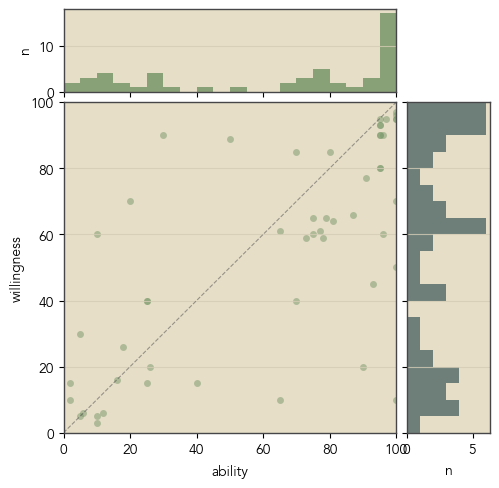

In [7]:
# joint scatter: ability vs willingness (all responses) w/ marginals
# item_means still needed for variance + RT cells
item_means = (trials
    .groupby('itemID')[['abilityResponse', 'willingnessResponse']]
    .mean()
    .reset_index()
)

c = PALETTES['primary'][0]
bins = range(0, 101, 5)

fig = plt.figure(figsize=(5.5, 5.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)
ax       = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

ax.scatter(trials['abilityResponse'], trials['willingnessResponse'],
           color=c, alpha=0.5, s=25, linewidths=0)
ax.axline((0, 0), slope=1, color='#464548', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('ability')
ax.set_ylabel('willingness')

ax_top.hist(trials['abilityResponse'], bins=bins, color=c, alpha=0.85)
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel('n')

ax_right.hist(trials['willingnessResponse'], bins=bins, color=PALETTES['primary'][1],
              alpha=0.85, orientation='horizontal')
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel('n')

# plt.suptitle(f'all responses (n={len(trials)})', x=0.42, y=1.01)
plt.show()

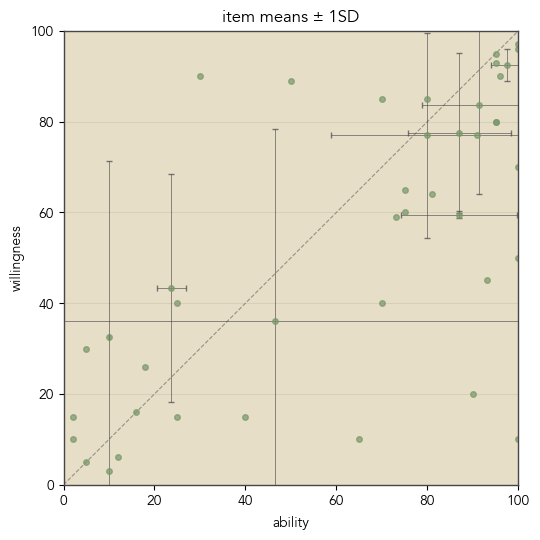

In [ ]:
# item variance: same scatter w/ ±1SD error bars
# item_stats = (trials
#     .groupby('itemID')[['abilityResponse', 'willingnessResponse']]
#     .agg(['mean', 'std'])
#     .reset_index()
# )
# item_stats.columns = ['itemID', 'ab_mean', 'ab_sd', 'wil_mean', 'wil_sd']

# fig, ax = plt.subplots(figsize=(5.5, 5.5))
# ax.errorbar(item_stats['ab_mean'], item_stats['wil_mean'],
#             xerr=item_stats['ab_sd'], yerr=item_stats['wil_sd'],
#             fmt='o', color=c, ecolor='#464548', elinewidth=0.6,
#             capsize=2, alpha=0.7, markersize=4, linewidth=0)
# ax.axline((0, 0), slope=1, color='#464548', lw=0.8, linestyle='--', alpha=0.5)
# ax.set_xlim(0, 100)
# ax.set_ylim(0, 100)
# ax.set_xlabel('ability')
# ax.set_ylabel('willingness')
# ax.set_title('item means ± 1SD')
# plt.tight_layout()
# plt.show()

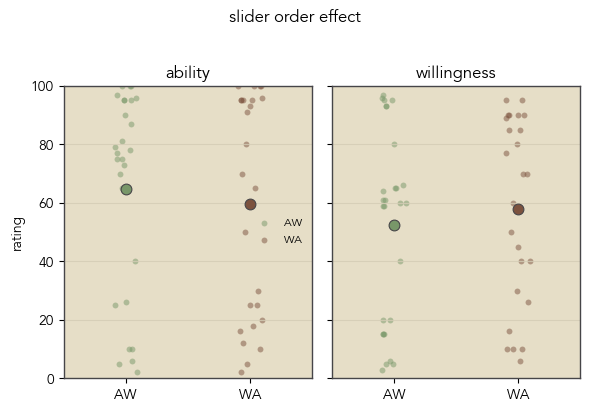

In [ ]:
# slider order effect: ability + willingness by AW vs WA
# order_colors = {'AW': PALETTES['primary'][0], 'WA': PALETTES['primary'][2]}
# jitter = 0.1

# fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
# for ax, col, label in zip(axes,
#                            ['abilityResponse', 'willingnessResponse'],
#                            ['ability', 'willingness']):
#     for i, (order, grp) in enumerate(trials.groupby('sliderOrder')):
#         x = np.full(len(grp), i) + np.random.uniform(-jitter, jitter, len(grp))
#         ax.scatter(x, grp[col], color=order_colors[order], alpha=0.5, s=18, linewidths=0, label=order)
#         ax.scatter(i, grp[col].mean(), color=order_colors[order], s=60, zorder=5,
#                    edgecolors='#464548', linewidths=0.8)
#     ax.set_xticks([0, 1])
#     ax.set_xticklabels(['AW', 'WA'])
#     ax.set_xlim(-0.5, 1.5)
#     ax.set_ylim(0, 100)
#     ax.set_title(label)

# axes[0].set_ylabel('rating')
# axes[0].legend(frameon=False, fontsize=8)
# plt.suptitle('slider order effect', y=1.02)
# plt.tight_layout()
# plt.show()

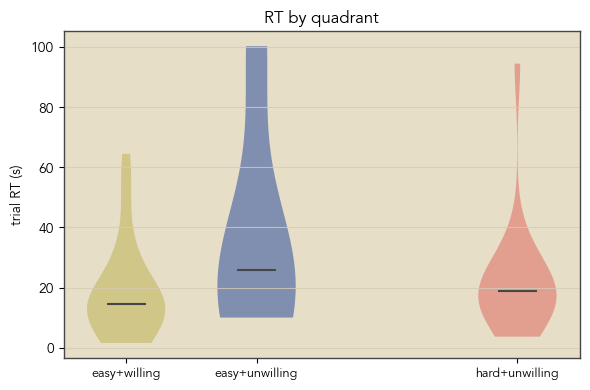

In [ ]:
# RT by quadrant — assign each trial to a quadrant via item means
# trials_q = trials.merge(item_means, on='itemID', suffixes=('', '_mean'))
# mid = 50
# trials_q['quadrant'] = trials_q.apply(
#     lambda r: ('high-ab' if r['abilityResponse_mean'] >= mid else 'low-ab') + ' / ' +
#               ('high-wil' if r['willingnessResponse_mean'] >= mid else 'low-wil'),
#     axis=1
# )

# quad_order  = ['high-ab / high-wil', 'high-ab / low-wil', 'low-ab / high-wil', 'low-ab / low-wil']
# quad_labels = ['easy+willing', 'easy+unwilling', 'hard+willing', 'hard+unwilling']
# quad_colors = PALETTES['four_colors']

# fig, ax = plt.subplots(figsize=(6, 4))
# plotted = []
# for i, (q, label, col) in enumerate(zip(quad_order, quad_labels, quad_colors)):
#     grp = trials_q[trials_q['quadrant'] == q]['trialRT'].dropna() / 1000
#     if len(grp) < 2:
#         continue
#     parts = ax.violinplot(grp, positions=[i], widths=0.6, showmedians=True, showextrema=False)
#     parts['bodies'][0].set_facecolor(col)
#     parts['bodies'][0].set_alpha(0.8)
#     parts['cmedians'].set_color('#464548')
#     parts['cmedians'].set_linewidth(1.5)
#     plotted.append((i, label))

# if plotted:
#     ax.set_xticks([i for i, _ in plotted])
#     ax.set_xticklabels([l for _, l in plotted], fontsize=9)
# else:
#     ax.text(0.5, 0.5, 'not enough data yet', transform=ax.transAxes, ha='center')

# ax.set_ylabel('trial RT (s)')
# ax.set_title('RT by quadrant')
# plt.tight_layout()
# plt.show()